# Why Tokenization?

Motivation: Machines can’t directly process raw text → need numerical representation.

Token vs word vs subword → why not just words? (OOV issue, morphology, efficiency).

Examples of different tokenizers:

    Word-level (old NLP, huge vocab)
    Character-level (fine-grained, inefficient for long sequences)
    Subword-level (BPE, WordPiece, SentencePiece → what LLMs use).

# Raw Text → Tokens

In [ ]:
# Types of Tokenizers

Byte-Pair Encoding (BPE) → merging frequent pairs.
WordPiece → likelihood-based merges.
SentencePiece → language-agnostic, handles raw text.
Byte-level (used in GPT-2/3) → stable across languages & unicode.
Trade-offs: vocab size, speed, memory.

# Byte Pair Encoding

1. Start with characters as tokens.
Example: "unbelievable" → [ "u", "n", "b", "e", "l", "i", "e", "v", "a", "b", "l", "e" ]

2. Find the most frequent pair of adjacent symbols in the training corpus.
Suppose "e" + "v" is very frequent.

3. Merge that pair into a new symbol.
Now "e" "v" → "ev" becomes a token.

4. Repeat thousands of times.
Over time, frequent words or subwords like "un", "believe", "able" become single tokens.
Rare words are still broken down into smaller pieces.


In [ ]:
| **Tokenizer**                | **Key Idea**                                                                            | **Example (word: “unbelievable”)**                | **Strengths**                                                                           | **Weaknesses**                                          |
| ---------------------------- | --------------------------------------------------------------------------------------- | ------------------------------------------------- | --------------------------------------------------------------------------------------- | ------------------------------------------------------- |
| **BPE (Byte-Pair Encoding)** | Merge **most frequent symbol pairs** in corpus                                          | `["un", "believe", "able"]`                       | Efficient, easy to implement, widely used                                               | Greedy, ignores context, may produce odd splits         |
| **WordPiece**                | Merge based on **likelihood gain** (how much it improves LM probability)                | `["un", "##believ", "##able"]`                    | Produces linguistically meaningful subwords, reduces rare-token issues                  | Slightly slower training; still not language-agnostic   |
| **SentencePiece**            | Treats text as raw stream (no whitespace assumption); builds subwords using BPE/Unigram | `["▁un", "believable"]` (`▁` marks word boundary) | Works across languages, handles no spaces (e.g., Japanese, Chinese), simple integration | Can feel “unnatural” to humans (strange splits)         |
| **Byte-level BPE (GPT-2/3)** | Operates directly on bytes; merges frequent byte pairs                                  | `["un", "believ", "able"]`                        | Universal: handles any unicode (emojis, symbols, multilingual text), no OOV             | Longer sequences for some languages, less interpretable |

In [ ]:
BPE → simple frequency-based.

WordPiece → probability-based.

SentencePiece → language-agnostic, raw text handling.

Byte-level BPE → modern standard for GPT-family, robust to anything you throw at it.

In [ ]:
1. Word-level tokenizer (old NLP)

Splits by whitespace or simple rules.
"unbelievable" → [ "unbelievable" ]

Problem: If model has never seen "unbelievable", it’s OOV (out-of-vocabulary).

2. Character-level tokenizer

Splits every character.
"unbelievable" → [ "u", "n", "b", "e", "l", "i", "e", "v", "a", "b", "l", "e" ]
Advantage: No OOV. Disadvantage: long sequences, inefficient.

3. Subword-level (BPE / WordPiece)

Breaks words into smaller frequent units.

Example with Byte Pair Encoding (used in GPT-2, RoBERTa):
"unbelievable" → [ "un", "believe", "able" ]

Example with WordPiece (used in BERT):
"unbelievable" → [ "un", "##believ", "##able" ]
(## indicates it’s a continuation token).

4. Byte-level BPE (GPT family)

Works directly on bytes (more universal).
"unbelievable" → [ "un", "believ", "able" ]

Always possible to encode any string (even emojis, symbols).

In [ ]:
# Install requirements if needed:
# pip install transformers tiktoken
!pip install tiktoken
from transformers import AutoTokenizer
import tiktoken

text = "unbelievable"

print("\nInput text:", text)

# 1. Word-level tokenizer
word_tokens = text.split()  # simple whitespace split
print("\n1. Word-level:", word_tokens)

# 2. Character-level tokenizer
char_tokens = list(text)
print("2. Char-level:", char_tokens)

# 3a. Subword-level (BPE: GPT-2 / RoBERTa style)
gpt2_tok = AutoTokenizer.from_pretrained("gpt2")
print("3a. BPE (GPT-2):", gpt2_tok.tokenize(text))

# 3b. Subword-level (WordPiece: BERT style)
bert_tok = AutoTokenizer.from_pretrained("bert-base-uncased")
print("3b. WordPiece (BERT):", bert_tok.tokenize(text))

# 4. Byte-level BPE (used in GPT-3/4)
enc = tiktoken.get_encoding("cl100k_base")  # OpenAI tokenizer
ids = enc.encode(text)
print("4. Byte-level BPE (OpenAI):", ids)
print("   Decoded back:", enc.decode(ids))


   ---------------------------------------- 0.0/883.9 kB ? eta -:--:--
   --------------------------------------- 883.9/883.9 kB 13.6 MB/s eta 0:00:00

Input text: unbelievable

1. Word-level: ['unbelievable']
2. Char-level: ['u', 'n', 'b', 'e', 'l', 'i', 'e', 'v', 'a', 'b', 'l', 'e']
3a. BPE (GPT-2): ['un', 'bel', 'iev', 'able']
3b. WordPiece (BERT): ['unbelievable']
4. Byte-level BPE (OpenAI): [359, 32898, 24694]
   Decoded back: unbelievable


In [ ]:
!pip install transformers

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ----------------------- ---------------- 6.6/11.3 MB 34.7 MB/s eta 0:00:01
   ---------------------------------------  11.0/11.3 MB 28.4 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 26.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/561.5 kB ? eta -:--:--
   --------------------------------------- 561.5/561.5 kB 18.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 16.5 MB/s eta 0:00:00

   ---------- ----------------------------- 1/4 [huggingface-hub]
   ---------- ----------------------------- 1/4 [huggingface-hub]
   -------------------- ------------------- 2/4 [tokenizers]
   ------------------------------ --------- 3/4 [transformers]
   ------------------------------ --------- 3/4 [transformers]
   ------------------------------ --------- 3/4 [transformers]
   -----------

In [ ]:
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained("gpt2")
print(tok.tokenize("unbelievable cats playing piano"))
print(tok("unbelievable cats playing piano")["input_ids"])


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\fedex\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Error while downloading from https://huggingface.co/gpt2/resolve/main/tokenizer.json: HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out.
Trying to resume download...


tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

['un', 'bel', 'iev', 'able', 'Ġcats', 'Ġplaying', 'Ġpiano']
[403, 6667, 11203, 540, 11875, 2712, 19132]


# From Tokens → Embeddings

In [ ]:
From Tokens → Embeddings

Definition: Embedding = vector representation of tokens in continuous space.
Embedding matrix: vocab_size × hidden_dim.

Why embeddings? → capture semantic & syntactic similarity.
Word embeddings (Word2Vec, GloVe) vs contextual embeddings (BERT, GPT).

Example:
     Static embedding: “bank” = same vector always.
     Contextual embedding: “river bank” vs “money bank” → different vectors.

For Visualization:
      I had used sklearn.manifold.TSNE to plot embeddings for words like king, queen, man, woman.

In [ ]:
# An example of embedding matrix
import numpy as np

vocab = {"un":0, "believe":1, "able":2, "cats":3}
print("Vocabulary:", vocab)

# Embedding matrix: vocab_size x hidden_dim
# Here: 4 tokens, embedding size = 5
embedding_dim = 5
embedding_matrix = np.random.randn(len(vocab), embedding_dim)

#POINT TO NOTE:  #You have an embedding matrix of shape [vocab_size, hidden_dim]. Each row corresponds to one token’s vector.

print("\nEmbedding matrix shape:", embedding_matrix.shape)
print(embedding_matrix)

# Example: lookup for the word "believe"
token = "believe"
token_id = vocab[token]
embedding_vector = embedding_matrix[token_id]

print(f"\nToken: '{token}'")
print("Token ID:", token_id)
print("Embedding vector:", embedding_vector)


Vocabulary: {'un': 0, 'believe': 1, 'able': 2, 'cats': 3}

Embedding matrix shape: (4, 5)
[[ 0.23648681  0.09865862  1.33435537 -1.83371094  0.47599872]
 [-0.8492629   0.04846054 -0.2322489  -1.60822979  0.63139617]
 [ 0.06639776 -0.64486137 -0.45786755 -0.62732145  0.22300147]
 [-0.58111714  0.42146096 -0.03868578  0.02515092  0.21962479]]

Token: 'believe'
Token ID: 1
Embedding vector: [-0.8492629   0.04846054 -0.2322489  -1.60822979  0.63139617]


## So it is basically deep learning libraries skip that multiplication and just do a fast row lookup.

In [ ]:
# 1. Static embeddings (Word2Vec / GloVe style)

Each word has one fixed vector, no matter where it appears.

"bank" will always map to the same numbers.

In [ ]:
#2. Contextual embeddings (BERT / GPT style)

The same word gets different vectors depending on context.

"river bank" vs "money bank" → different vectors for "bank".

In [ ]:
# Example
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Load BERT
tok = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")

# Sentences with same word in different contexts
sents = ["I went to the river bank to fish.",
         "She deposited money in the bank yesterday."]

def get_word_embedding(sentence, target_word):
    # Tokenize
    inputs = tok(sentence, return_tensors="pt")
    outputs = model(**inputs)
    # Get embeddings from last hidden layer
    embeddings = outputs.last_hidden_state.squeeze(0).detach()

    # Find position of target word (rough approach)
    tokens = tok.tokenize(sentence)
    ids = tok(sentence)["input_ids"]
    # Find index of first occurrence of target word
    for i, t in enumerate(tokens):
        if target_word in t:   # crude match, better to check carefully
            return embeddings[i+1].numpy()  # +1 to skip [CLS]

# Get embeddings of "bank" in both contexts
vec1 = get_word_embedding(sents[0], "bank")
vec2 = get_word_embedding(sents[1], "bank")

print("Cosine similarity between 'bank' (river vs money):",
      cosine_similarity([vec1],[vec2])[0][0])


Cosine similarity between 'bank' (river vs money): 0.5464635


In [ ]:
Thus,

“In old NLP (Word2Vec, GloVe), bank = one fixed vector, always.”

“In BERT/GPT, embeddings depend on the sentence context — so bank in river bank ≠ bank in money bank.”

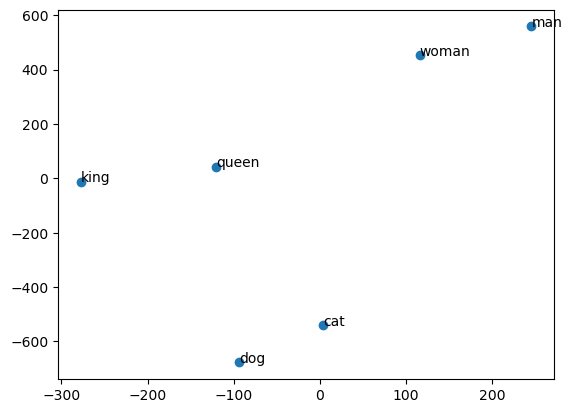

In [ ]:
# Embeddings

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer, AutoModel
import torch

words = ["king", "queen", "man", "woman", "cat", "dog"]
tok = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")

embs = []
for w in words:
    ids = tok(w, return_tensors="pt")
    vec = model(**ids).last_hidden_state.mean(1).detach().numpy()
    embs.append(vec[0])

X = TSNE(n_components=2, perplexity=2, random_state=42).fit_transform(np.array(embs))

plt.scatter(X[:,0], X[:,1])
for i,w in enumerate(words):
    plt.annotate(w, (X[i,0], X[i,1]))
plt.show()



# Applications of Embeddings

### Semantic similarity (cosine similarity → search engines).
### Clustering topics (document clustering).
### Input to downstream models (classification, NER).
### Retrieval-Augmented Generation (RAG): embeddings as building block for search + LLM.

In [ ]:
# 1 Semantic similarity (cosine similarity → search engines).

Idea: Similar words/sentences have embedding vectors pointing in similar directions.
Use case: “nearest neighbor” search for Q&A, semantic search.

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity

# Load BERT (small version to keep it fast)
tok = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")

def sentence_embedding(sentence):
    """Get average embedding of a sentence from BERT last hidden state"""
    inputs = tok(sentence, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)
    # Mean pooling across tokens
    emb = outputs.last_hidden_state.mean(dim=1).detach().numpy()
    return emb

# Sentences
s1 = "I sat by the river bank and caught a fish."
s2 = "She went to the bank to deposit her paycheck."
s3 = "The fisherman caught a fish in the river."

# Compute embeddings
e1 = sentence_embedding(s1)
e2 = sentence_embedding(s2)
e3 = sentence_embedding(s3)

# Compare similarities
print("sim(river bank, money bank):", cosine_similarity(e1, e2)[0][0])
print("sim(river bank, fisherman):", cosine_similarity(e1, e3)[0][0])


sim(river bank, money bank): 0.6583677
sim(river bank, fisherman): 0.82448584


In [ ]:
# 2 Clustering topics (document clustering).

Clustering Topics (document clustering)

Idea: Represent documents as embeddings, then cluster with k-means.

Use case: News articles grouped by topic, customer reviews grouped by theme.

In [ ]:
#!pip install sentence-transformers scikit-learn you need to install this

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

# Load a sentence embedding model (fast + good quality)
model = SentenceTransformer("all-MiniLM-L6-v2")

# Sample documents (2 topics: finance vs animals)
docs = [
    "I deposited money in the bank.",
    "She applied for a loan from the bank.",
    "The fisherman sat by the river bank.",
    "The cat chased a fish near the river."
]

# Get embeddings
embeddings = model.encode(docs)

# Cluster into 2 groups
kmeans = KMeans(n_clusters=2, random_state=42).fit(embeddings)
labels = kmeans.labels_

# Print clusters
for doc, label in zip(docs, labels):
    print(f"Cluster {label}: {doc}")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\fedex\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Cluster 0: I deposited money in the bank.
Cluster 0: She applied for a loan from the bank.
Cluster 1: The fisherman sat by the river bank.
Cluster 1: The cat chased a fish near the river.


C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [ ]:
# 3. Input to Downstream Models (classification, NER, etc.)

Idea: Embeddings act as features.

Use case:
Sentiment classification (positive/negative).
Named Entity Recognition (NER) → detect people/places.
Instead of raw text, the classifier gets dense vectors.

# Replacing the manual feature engineered characters with Embeddings.

In [ ]:
# pip install sentence-transformers scikit-learn
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load sentence embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Sample dataset (tiny for demo)
sentences = [
    "I love this movie, it was fantastic!",
    "What a great experience, I’m so happy.",
    "The food was terrible and I hated it.",
    "Worst service ever, I will not come back.",
    "The book was inspiring and beautifully written.",
    "I’m disappointed, the product broke immediately."
]
labels = [1, 1, 0, 0, 1, 0]  # 1 = Positive, 0 = Negative

# Convert sentences → embeddings
embeddings = model.encode(sentences)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, test_size=0.3, random_state=42
)

# Train a simple classifier
clf = LogisticRegression()
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.0


In [ ]:
4. Retrieval-Augmented Generation (RAG) # -> We will look more into this once Ramji sir covers this

Idea: Embeddings enable semantic search inside a vector database (FAISS, Pinecone, Weaviate).

Pipeline: User query → embedding → vector search → top documents → LLM consumes them.

Use case: Enterprise Q&A, domain-specific chatbots.

# Raw text → Token IDs → Embedding vectors → Transformer.
# This is  what happens before the model even starts attention layers.